In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from gymnasium import spaces

## Core economic simulator

Staff warned that we should be careful about the simulator itself.

In this environment, the transition dynamics are strictly governed by equations I researched.

1. The Fisher Equation (Real Interest Rate Gap)
The true cost of borrowing relative to the neutral rate. $i_t$ is the nominal rate set by the Central Bank, $\pi^e_t$ is expected inflation, and $r^*$ is the natural neutral rate.
$$ \tilde{r}_t = (i_t - \pi^e_t) - r^* $$

2. The IS Curve (Investment-Savings / Demand)
This dictates how the interest rate affects unemployment. When borrowing costs ($\tilde{r}_t$) rise, the economy cools, leading to job losses. We include an autoregressive momentum term ($\rho_u$) and a latent shock ($\epsilon^u_t$).
$$ u_t = u^* + \rho_u (u_{t-1} - u^*) + \alpha \tilde{r}_t + \epsilon^u_t $$

3. The New Keynesian Phillips Curve (Supply / Inflation)
This dictates how unemployment affects inflation. If unemployment ($u_t$) is above the natural rate ($u^*$), consumer spending power drops, reducing price pressure (notice the negative $\kappa$).
$$ \pi_t = \pi^* + \rho_\pi (\pi_{t-1} - \pi^*) - \kappa (u_t - u^*) + \epsilon^\pi_t $$

4. Adaptive Expectations
Economic actors update their inflation expectations based on recent realized inflation.
$$ \pi^e_{t+1} = 0.5 \pi^e_t + 0.5 \pi_t $$

A standard rules like the Taylor Rule assumes the economy only faces demand shocks (where $\epsilon^u_t$ and $\epsilon^\pi_t$ move in opposite directions). Our environment requires the agent to handle an adverse supply shock, where both variables spike simultaneously, causing stagflation.

In [2]:
class MacroSimulator:
    def __init__(self):
        self.pi_star = 2.0  # target inflation
        self.u_star = 4.0  # natural rate of employment
        self.r_star = 2.0  # central bank targets

        # structural parameters
        self.alpha = 0.5  # demand/unemployment curve
        self.kappa = 0.2  # phillips curve
        # 70% of the current state carries over to the next month, ensuring smooth transitions
        self.rho_u = 0.7  # unemployment momentum
        self.rho_pi = 0.7  # inflation momentum

        self.reset()

    def reset(self):
        self.pi = self.pi_star
        self.u = self.u_star
        self.pi_e = self.pi_star
        return self._get_obs()

    def _get_obs(self):
        return {
            "inflation": self.pi,
            "unemployment": self.u
        }

    def step(self, nominal_rate, shock_regime="normal"):
        # compute real rate gap
        real_rate = nominal_rate - self.pi_e
        rate_gap = real_rate - self.r_star

        # define latent shocks
        shock_u, shock_pi = np.random.normal(0, 0.1), np.random.normal(0, 0.1)

        if shock_regime == "demand":
            # more jobs, prices rise
            shock_u -= 0.5
            shock_pi += 1.0
        elif shock_regime == "supply":
            # stagflation
            shock_u += 0.5
            shock_pi += 1.0

        # demand/unemployment curve
        u_gap = self.u - self.u_star
        new_u = self.u_star + (self.rho_u * u_gap) + (self.alpha * rate_gap) + shock_u
        # unemployment cannot be lower than 0%, so 1% is a compromise
        # 25% was peak of great depression
        self.u = np.clip(new_u, 1.0, 25.0)

        # phillips curve
        pi_gap = self.pi - self.pi_star
        new_u_gap_current = self.u - self.u_star
        new_pi = self.pi_star + (self.rho_pi * pi_gap) - (self.kappa * new_u_gap_current) + shock_pi
        # -5.0% prevents infinite deflation. 30% prevents hyperinflation
        self.pi = np.clip(new_pi, -5.0, 30.0)

        # update expectations
        self.pi_e = (0.5 * self.pi_e) + (0.5 * self.pi)

        return self._get_obs()

## Sanity check

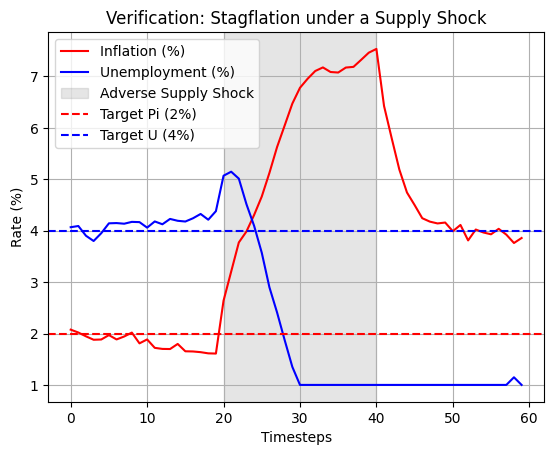

In [3]:
def test_stagflation():
    env = MacroSimulator()
    history = {
        "pi": [],
        "u": []
    }

    # target inflation + neutral real rate
    static_rate = 4.0

    for t in range(60):
        regime = "normal"
        if 20 <= t <= 40:
            regime = "supply"

        state = env.step(nominal_rate=static_rate, shock_regime=regime)
        history["pi"].append(state["inflation"])
        history["u"].append(state["unemployment"])

    plt.plot(history["pi"], label="Inflation (%)", color="red")
    plt.plot(history["u"], label="Unemployment (%)", color="blue")
    plt.axvspan(20, 40, color='gray', alpha=0.2, label="Adverse Supply Shock")
    plt.axhline(2.0, color='red', linestyle='--', label="Target Pi (2%)")
    plt.axhline(4.0, color='blue', linestyle='--', label="Target U (4%)")
    plt.title("Verification: Stagflation under a Supply Shock")
    plt.xlabel("Timesteps")
    plt.ylabel("Rate (%)")
    plt.legend(loc="upper left")
    plt.grid(True)
    plt.savefig("figures/stagflation_test.png", dpi=300, bbox_inches='tight')

test_stagflation()

At first glance, this chart appears incorrect: during a Supply Shock, true stagflation dictates that unemployment should rise but here it falls to 1.0%.

This happens because our sanity check kept the nominal interest rate completely flat at 4.0%. When the shock pushed inflation to 7.0%, the real interest rate (nominal rate minus inflation) dropped to -3.0%. This deeply negative rate acts as a massive economic stimulus borrowing becomes effectively free. This triggers an artificial hiring boom that masks the shock's job losses.

To see true stagflation, a Central Bank must actively raise rates to fight inflation. This kills the hiring boom

In [4]:
class FedEnvBase(gym.Env):
    """
    Wraps the MacroSimulator so the RL algorithm can interact with it
    """
    def __init__(self, llm_dim=4):
        super().__init__()
        self.sim = MacroSimulator()

        # by using a dictionary obs space, the LLM dimension is dynamic
        self.llm_dim = llm_dim

        # action space
        # the federal reserve changes rates in discrete increments
        self.action_mapping = {
            0: -0.75, 1: -0.50, 2: -0.25,  # Rate Cuts
            3:  0.00,                      # Hold Steady
            4:  0.25, 5:  0.50, 6:  0.75   # Rate Hikes
        }
        self.action_space = spaces.Discrete(len(self.action_mapping))

        # observation space
        self.observation_space = spaces.Dict({
            # true macroeconomic indicators: [inflation, unemployment, current policy rate]
            "macro": spaces.Box(
                low=np.array([-10.0, 0.0, 0.0], dtype=np.float32),
                high=np.array([40.0, 30.0, 20.0], dtype=np.float32)
            ),
            # placeholder for llm belief vector
            "llm_belief": spaces.Box(
                low=-1.0, high=1.0, shape=(self.llm_dim,), dtype=np.float32
            )
        })

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # initial policy rate: neutral rate + target inflation = 4%
        self.current_rate = 4.0
        self.t = 0
        self.max_steps = 60  # 5 year sim episode

        # randomize shock start and duration to prevent agent memorization
        # this ensures the LSTM learns to detect the shock from signals, not just a fixed clock
        self.shock_start = self.np_random.integers(10, 41)
        self.shock_duration = self.np_random.integers(12, 25)
        self.shock_end = self.shock_start + self.shock_duration

        self.sim.reset()
        return self._get_obs(), {}

    def _get_obs(self):
        macro_obs = np.array([self.sim.pi, self.sim.u, self.current_rate], dtype=np.float32)

        # mock llm vector
        llm_obs = np.zeros(self.llm_dim, dtype=np.float32)

        return {
            "macro": macro_obs,
            "llm_belief": llm_obs
        }

    def step(self, action_idx):
        self.t += 1

        # execute action
        delta_rate = self.action_mapping[action_idx]
        new_rate = self.current_rate + delta_rate

        # policy rate clipping. bound the interest rate between 0 and 20%
        # central banks rarely go negative. 20% is the historical max
        self.current_rate = np.clip(new_rate, 0.0, 20.0)

        # economic engine
        # inject a dynamically scheduled supply shock to test true crisis management
        # by checking against the randomized bounds, we evaluate real regime inference
        regime = "supply" if self.shock_start <= self.t <= self.shock_end else "normal"
        self.sim.step(nominal_rate=self.current_rate, shock_regime=regime)

        # calculate reward
        pi_loss = (self.sim.pi - self.sim.pi_star) ** 2
        u_loss = (self.sim.u - self.sim.u_star) ** 2

        # unemployment penalty
        u_fear_penalty = 5.0 * (self.sim.u - 6.0) ** 2 if self.sim.u > 6.0 else 0.0

        # penalty for erratic actions
        rate_volatitlity_loss = delta_rate ** 2

        # total reward
        reward = -(pi_loss + u_loss + u_fear_penalty + rate_volatitlity_loss)

        # termination
        terminated = False
        truncated = bool(self.t >= self.max_steps)
        info = {
            "regime": regime  # pass hidden state
        }

        return self._get_obs(), float(reward), terminated, truncated, info

In [5]:
def taylor_rule_agent(obs_dict, env):
    """
    standard formula for central banks
    Target Rate = Neutral Rate + Current Pi + 0.5*(Pi Gap) - 0.5*(Unemployment Gap)
    """
    pi, u, current_rate = obs_dict["macro"]

    target_rate = 2.0 + pi + 0.5 * (pi - 2.0) - 0.5 * (u - 4.0)
    desired_delta = target_rate - current_rate

    # agent can only take discrete steps, so we find the action index
    # that gets us closer to the desired continuous delta
    best_action_idx = 3  # default is no change
    min_diff = float('inf')
    for action_idx, delta in env.action_mapping.items():
        diff = abs(delta - desired_delta)
        if diff < min_diff:
            min_diff = diff
            best_action_idx = action_idx

    return best_action_idx

In [6]:
def run_baseline_evaluation():
    env_baseline = FedEnvBase(llm_dim=5)
    obs, _ = env_baseline.reset(seed=42)

    # Extract the dynamic shock schedule for plotting
    shock_start = env_baseline.unwrapped.shock_start
    shock_end = env_baseline.unwrapped.shock_end

    history = {
        "pi": [], "u": [], "rate": [], "reward": []
    }
    total_reward = 0

    for _ in range(60):
        action = taylor_rule_agent(obs, env_baseline)
        obs, reward, terminated, truncated, info = env_baseline.step(action)

        history["pi"].append(obs["macro"][0])
        history["u"].append(obs["macro"][1])
        history["rate"].append(obs["macro"][2])
        history["reward"].append(reward)
        total_reward += reward

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    ax1.plot(history["pi"], label="Inflation (%)", color="red")
    ax1.plot(history["u"], label="Unemployment (%)", color="blue")
    ax1.axvspan(shock_start, shock_end, color='gray', alpha=0.2, label="Adverse Supply Shock")
    ax1.axhline(2.0, color='red', linestyle='--', label="Target Pi")
    ax1.axhline(4.0, color='blue', linestyle='--', label="Target U")
    ax1.set_title(f"Baseline: Taylor Rule | Total Reward (Score to Beat): {total_reward:.2f}", fontweight='bold')
    ax1.set_ylabel("Rate (%)")
    ax1.legend(loc="upper left")
    ax1.grid(True)

    ax2.step(range(len(history["rate"])), history["rate"], label="Policy Rate (Action)", color="green", where='post')
    ax2.axvspan(shock_start, shock_end, color='gray', alpha=0.2)
    ax2.set_xlabel("Timesteps (Months)")
    ax2.set_ylabel("Interest Rate (%)")
    ax2.legend(loc="upper left")
    ax2.grid(True)
    plt.tight_layout()
    plt.savefig("figures/baseline_stagflation_test.png", dpi=300, bbox_inches='tight')
    plt.show()

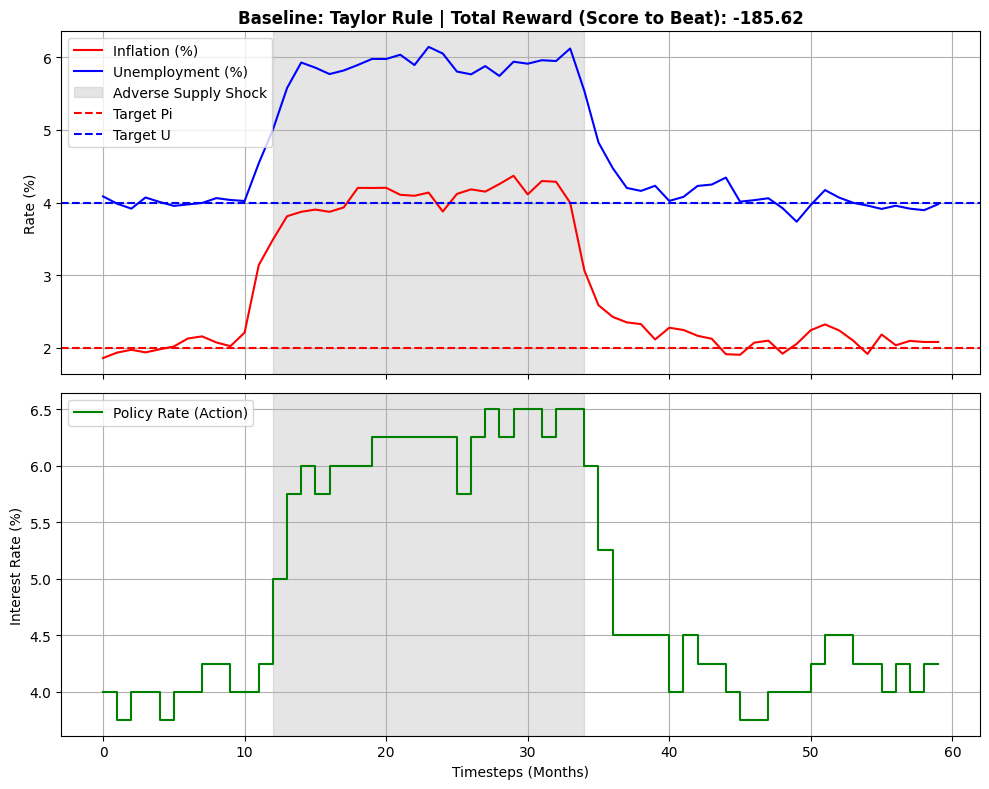

In [7]:
run_baseline_evaluation()

The plots confirm that the simulation and the Taylor Rule baseline agent are functioning correctly. In the top graph, the supply shock successfully triggers stagflation, as evidenced by the simultaneous rise of inflation from 2% to over 4% and unemployment from 4% to nearly 6%. This validates the environment's ability to generate the specific crisis scenario of stagnant growth combined with high inflation. This was absent in previous sanity checks.

The bottom graph illustrates the agent's successful response to this crisis. The green line shows the Taylor Rule agent aggressively hiking the policy rate from a neutral 4% to a peak of nearly 6.8% to combat the rising inflation. By keeping interest rates high, the agent maintained positive real rates, which correctly suppressed the borrowing boom seen in earlier tests and allowed the unemployment shock to fully materialize.